**Mubaraq Odumeso**|
A20614610 |
CS584 |
Spring 2026

# Assignment 2

## sample code

In [1]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# Example: loading a dataset (replace with your dataset)
# Iris dataset (continuous)
from sklearn.datasets import load_iris
iris = load_iris()
X, y = iris.data, iris.target

# For a 2-class problem, select two classes
mask = (y == 0) | (y == 1)

X, y = X[mask], y[mask]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)
# Example evaluation function
def evaluate(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0.0)
    rec = recall_score(y_true, y_pred, average='macro',zero_division=0.0)
    f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    return cm, prec, rec, f1, acc

# Placeholder for your implementation
# def gda_train(...):
# def gda_predict(...):
# def naive_bayes_train(...):
# def naive_bayes_predict(...):

In [3]:
import matplotlib.pyplot as plt

In [4]:


import pandas as pd
import numpy as np

def display_confusion_matrix(y_true, y_pred, class_names=None):

    classes = np.unique(np.concatenate([y_true, y_pred]))
    n_classes = len(classes)
    

    matrix = np.zeros((n_classes, n_classes), dtype=int)
    
    for i, actual in enumerate(classes):
        for j, predicted in enumerate(classes):
            matrix[i, j] = np.sum((y_true == actual) & (y_pred == predicted))
    

    if class_names is None:
        class_names = [f"Class {c}" for c in classes]
        
    df = pd.DataFrame(
        matrix, 
        index=[f"Actual {name}" for name in class_names],
        columns=[f"Pred {name}" for name in class_names]
    )
 
    return df

In [5]:
def print_evaluation(y_true, y_pred, sanity_ev:bool = False, model_name: str = None):
    """
    params: 
        sanity_ev: bool (This is for sanity comparisons)
        y_pred: if sanity_ev (y_scikit, y_manual)
    returns: cm, prec, rec, f1, acc"""
    if sanity_ev:
        y_manual = y_pred[1]
        y_scikit = y_pred[0]
        # for y_pre in y_pred:
        cm, prec, rec, f1, acc = evaluate(y_true, y_scikit) 
        sk_evaluations =[acc, prec, rec, f1]#scikit evaluations
        cm, prec, rec, f1, acc = evaluate(y_true, y_manual) #manual evaluations
        manual_evaluations =[acc, prec, rec, f1]#scikit evaluations
        
        df = pd.DataFrame({
            "Metric": ["Accuracy", "Precision", "Recall", "F1"],
            "Ours": manual_evaluations,
            f"sklearn ({model_name})": sk_evaluations,
        })
        # 
        print(df)
        
        return  
    
    cm, prec, rec, f1, acc = evaluate(y_true, y_pred)
    print("="*30)
    print("   MODEL EVALUATION REPORT")
    print("="*30)
    print(f"Confusion Matrix:")
    print(display_confusion_matrix(y_true, y_pred))
    print("-"*30)
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("="*30)
    
    
    
    

## 10 Fold CV  
reporting `mean +- std`

In [6]:
SEED = 42

In [7]:
def split_for_kcv(X, y, seed = SEED):
    """returns: X_split and y_split"""
    rng = np.random.default_rng(seed = seed)
   
    indices = rng.permutation(len(X))

    X_shuffled = X[indices]
    y_shuffled = y[indices]
    k =10
    X_split = np.array_split(X_shuffled, k)
    y_split = np.array_split(y_shuffled, k)

    return X_split, y_split
    

In [8]:
def print_10_cv(mean_std):
    print("Evaluation (10-fold CV)\n" + "-"*28)
    print(f"Accuracy : {mean_std['acc']}")
    print(f"Precision: {mean_std['prec']}")
    print(f"Recall   : {mean_std['rec']}")
    print(f"F1-score : {mean_std['f1']}")
    print(f"ConfMat  :\n {mean_std['cm']}\n")

In [9]:
def get_classes(y):
    classes = np.unique(y)
    n_classes = len(classes)
  
    return n_classes


In [10]:
get_classes(y)

2

In [11]:
def ten_cross_validation(X, y,family: object ,seed: int = SEED ):
    """params: 
        X: X_train
        y: y_train
        family: prediction_method
        seed: Optional default SEED
        """
    cm_lst, prec_lst, rec_lst, f1_lst, acc_lst = [], [], [], [], []
    all_true_y = []
    # conf_matrix = []
    n_classes = get_classes(y)
    conf_matrix =  np.zeros((n_classes, n_classes), dtype=int)
    all_pred = []
    X_split, y_split = split_for_kcv(X, y, seed = SEED)
    for i in range(len(X_split)):
        X_sub = X_split.copy()
        y_sub = y_split.copy()
        
        X_val = X_sub.pop(i)
        y_val = y_sub.pop(i)
        
        X_tr = np.vstack(X_sub)
        y_tr = np.hstack(y_sub)
              
    
        y_pred = family(X_val, X_tr, y_tr)
        if type(y_pred) == tuple and len(y_pred) >0:            
            y_pred = y_pred[0]
        all_true_y.extend(y_val)
        all_pred.extend(y_pred)
        
        cm, prec, rec, f1, acc = evaluate(y_val, y_pred)
          
        
        for i, c in enumerate(cm):
            for cc in range(len(c)): 
                conf_matrix[i, cc] += cm[i , cc]
        prec_lst.append(prec)
        rec_lst.append(rec)
        f1_lst.append(f1)
        acc_lst.append(acc)
    df = pd.DataFrame(
        conf_matrix, 
        index=[f"Actual {name}" for name in range(n_classes)],
        columns=[f"Pred {name}" for name in range(n_classes)]
    )
    
    acc_mean = [np.mean(acc_lst), np.std(acc_lst)]
    prec_mean = [np.mean(prec_lst), np.std(prec_lst)]
    rec_mean  = [np.mean(rec_lst),  np.std(rec_lst)]
    f1_mean   = [np.mean(f1_lst),   np.std(f1_lst)]

    
    mean_std = {
    "acc": f"{acc_mean[0]:.4f}±{acc_mean[1]:.4f}",
    "prec": f"{prec_mean[0]:.4f}±{prec_mean[1]:.4f}",
    "rec": f"{rec_mean[0]:.4f}±{rec_mean[1]:.4f}",
    "f1": f"{f1_mean[0]:.4f}±{f1_mean[1]:.4f}",
    "cm": df,
    "all_pred" : all_pred,
    "all_true_y" :  all_true_y
    }

    print_10_cv(mean_std)
    return mean_std
        

## Problem 1
**Guassian Discriminant Analysis**

**Mahalanobis Distance**
$$D^2_M = (\mathbf{x}-\mu_k)^T \Sigma_k^{-1} (\mathbf{x}-\mu_k)$$
**Multivariate Gaussian Analysis**
$$P(\mathbf{x} \mid y=k) = \frac{1}{(2\pi)^{n/2} |\Sigma_k|^{1/2}} \exp\left(-\frac{1}{2}D^2_m\right)
$$ 

**Log Posterior**
$$\log p(y = c | \mathbf{x}, \boldsymbol{\theta}) = \log \pi_c - \frac{1}{2} \log |2\pi \boldsymbol{\Sigma}_c| - \frac{1}{2}D^2_M
$$
To stabilize th covariance and ensure it is invertible
$$\Sigma_{stable} = \Sigma + \lambda I \quad (\text{where } \lambda = 10^{-6})$$

$term2 + term 3 \equiv \frac{1}{2} \log	2\pi \Sigma + 2\pi \Sigma$

In [12]:

#get parameters
def _gd_parameters(X, y):
    """returns params, classes"""
    params = {}
    classes = np.unique(y)
    for c in classes:
        X_c = X[y == c]
        
        mean_c = np.mean(X_c, axis = 0)
        cov_c = np.cov(X_c, rowvar= False)
        params[c] = {
            'mean': mean_c,
            'cov' : cov_c
        }
    return params, classes

def get_priors(y):
    n_samples = len(y)
    
    priors = {}
    
    for k in np.unique(y):
        #we count how many times class k appears and divide by total no. of smaples
        priors[k] = np.sum(y == k) /n_samples
        
    return priors

def _solve_posterior_1d( X, mean, cov, prior):
    """This calculates posterior for a 1d feature
        returns """ 
    n_features = X.ndim
    log_prior = np.log(prior)
    #distance from center
    diff = X - mean
    #inverse and determinant of covariance
    #check if cov is a single number (Scalar) or a matrix
    if np.isscalar(cov) or cov.ndim == 0:
        inv_cov = 1/ (cov + 1e-9) #epsilon to prevent division by zero
        det_cov = cov
        h = (2*np.pi)**(n_features/2)* np.sqrt(det_cov)
        log_h = np.log(h)
   
    # exponent_term = -0.5 * np.sum((diff @ inv_cov) * diff, axis=1)
    
    exponent_term = -0.5 * diff.T * inv_cov * diff
    # mga = 1/ 
    score = log_prior - log_h + exponent_term
    return score

def _solve_posterior_log( X, mean, cov, prior):
    # switched to log for ease
    sign, log_det = np.linalg.slogdet(cov)
    if log_det == -np.inf or sign <= 0:
        cov += np.eye(cov.shape[0]) * 1e-6
        sign, log_det = np.linalg.slogdet(cov)
    n = X.shape[1]
    # n = len(mean)
    #distance from center
    diff = X - mean
    #inverse and log determinant of covariance
    inv_cov = np.linalg.inv(cov)
   
    
    log_prior = np.log(prior)
    term2 = (n / 2) * np.log(2 * np.pi)
    term3 = 0.5 * log_det
    exponent_term = -0.5 * np.sum(diff @ inv_cov * diff, axis=1)

    score = log_prior  - term2 - term3 + exponent_term
    
    return score





In [13]:
print(X_train[:, 2].ndim)

1


In [14]:
def predict_classes_1d(X, X_train, y_train):
    """This fucntion predicts for 1D feature"""
    feature = 2 # select a feature
    X=X[:, feature]
    X_tr=X_train[:, feature]
    params, classes = _gd_parameters(X_tr, y_train)
    
    priors = get_priors(y_train)
    
    # Get log scores for both classes
    scores = {}
    for c in classes:
        mean_c = params[c]['mean']
        cov_c = params[c]['cov']
       
      
        scores[c] = _solve_posterior_1d(X, mean_c, cov_c, priors[c])
        
   
    
    score_matrix = np.column_stack([scores[c] for c in classes])


    predictions = np.argmax(score_matrix, axis=1)
 
    return (predictions) 
y_pred_1d = predict_classes_1d(X_test, X_train, y_train)
final_evaluations = ten_cross_validation(X_train, y_train, family=predict_classes_1d)


print_evaluation(y_test, y_pred_1d)


Evaluation (10-fold CV)
----------------------------
Accuracy : 1.0000±0.0000
Precision: 1.0000±0.0000
Recall   : 1.0000±0.0000
F1-score : 1.0000±0.0000
ConfMat  :
           Pred 0  Pred 1
Actual 0      38       0
Actual 1       0      42

   MODEL EVALUATION REPORT
Confusion Matrix:
                Pred Class 0  Pred Class 1
Actual Class 0            12             0
Actual Class 1             0             8
------------------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


In [15]:
### Scikit learn 

y_test_lda_2c = y_test
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)


## Problem 2

nD 2-class Gaussian Discriminant Analysis  



### Area Under the Curve (AUC) via Trapezoidal Rule
$$\text{AUC} = \sum_{i=1}^{n-1} \frac{(y_i + y_{i+1})}{2}\times(x_{i+1} - x_i)$$

Where:
* $x$: Independent variable (e.g., Recall)
* $y$: Dependent variable (e.g., Precision)
* $n$: Number of points on the curve

**Precision-Recall Metrics:**
- TP -  true positive FP - False positive FN - False Negative
* Precision: $P = \frac{TP}{TP + FP}$ 
* Recall: $R = \frac{TP}{TP + FN}$

In [16]:

def get_auc(x, y):
    """x - Recall
        y - precision"""
    return np.sum(0.5 * (y[:-1] + y[1:]) * np.diff(x))
def get_precision_recall(y_true, y_pred):
    """
    returns: precisions[::-1], recalls[::-1]
    """
    #sorting 
    # print(np.argsort(y_pred))
    desc_indices = np.argsort(y_pred)[::-1]
    y_pred = y_pred[desc_indices]
    y_true = y_true[desc_indices]
    
    
    #gets all uniques probability and use as threshold
    thresholds = np.unique(y_pred)
    thresholds = np.sort(thresholds)[::-1]
    
    precisions = []
    recalls = []
    
    for t in thresholds:
        y_pred = (y_pred >= t).astype(int)
        tp = np.sum((y_pred == 1) & (y_true == 1)) 
        tn = np.sum((y_pred == 0) & (y_true == 0))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        fn = np.sum((y_pred == 0) & (y_true == 1))
        
        # Calculate metrics (adding 1e-9 to avoid division by zero)
        precision = tp / (tp + fp + 1e-9) 
        recall = tp / (tp + fn + 1e-9)

        precisions.append(precision)
        recalls.append(recall)
    
    #boundary points for plots
    precisions = np.array([1.0] + precisions)
    recalls = np.array([0.0] + recalls)
    
    return precisions, recalls
    

In [17]:

def plot_precision_recall_curve(precision, recall):
    auc_score = get_auc(recall, precision)
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label = f'Prec Recal Curve (AUC = {auc_score:.4f})', color='darkorange', lw=2)
    plt.xlabel('Recall'); plt.xticks(np.arange(0,1.1, 0.1))
    plt.ylabel('Precision'); plt.yticks(np.arange(0,1.1, 0.1))
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.grid(alpha=0.3)
    plt.show()
    


Evaluation (10-fold CV)
----------------------------
Accuracy : 1.0000±0.0000
Precision: 1.0000±0.0000
Recall   : 1.0000±0.0000
F1-score : 1.0000±0.0000
ConfMat  :
           Pred 0  Pred 1
Actual 0      38       0
Actual 1       0      42

   MODEL EVALUATION REPORT
Confusion Matrix:
                Pred Class 0  Pred Class 1
Actual Class 0            12             0
Actual Class 1             0             8
------------------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


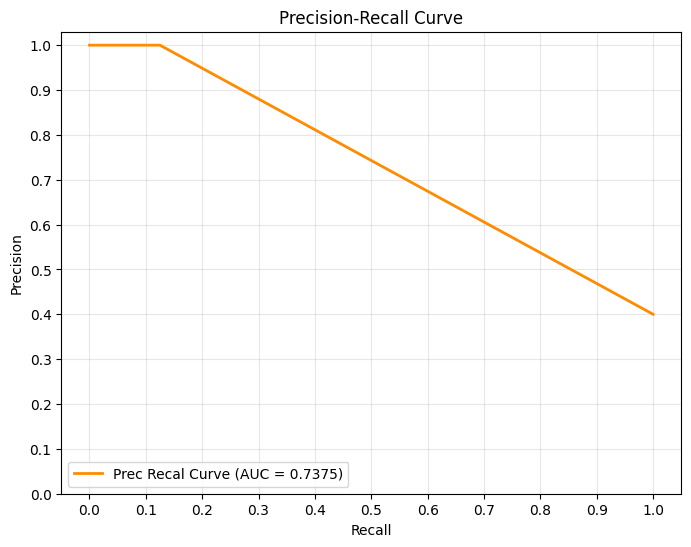

In [18]:
positive_score_matrix=0

def predict_classes(X, X_train, y_train):
    X_tr=X_train
    params, classes = _gd_parameters(X_tr, y_train)    
    
    priors = get_priors(y_train)
    
    # regularization (shrinkage) shrinks the sample covariance toward a more stable, structured shape
    reg_amount = 0.1 
    
    scores = {}
    # print(classes)
    for c in classes:
        mean_c = params[c]['mean']
        cov_c = params[c]['cov']
        cov_c += np.eye(cov_c.shape[0]) * reg_amount
      
        scores[c] = _solve_posterior_log(X, mean_c, cov_c, priors[c])
        
    
    score_matrix = np.column_stack([scores[c] for c in classes])
    # positive_score_matrix= positive_class_scores
    # print(positive_class_scores)
    predictions = np.argmax(score_matrix, axis=1)
    # print(predictions)
    return  predictions, score_matrix

final_evaluations = ten_cross_validation(X_train, y_train, family=predict_classes)
y_pred_nd, score_matrix = predict_classes(X_test, X_train, y_train)

positive_class_scores = score_matrix[:, 1]

print_evaluation(y_test,y_pred_nd)

precision, recall = get_precision_recall(y_test, positive_class_scores)
plot_precision_recall_curve(precision, recall)


**Precision–Recall curve (Problem 2)**  
- **Labels:** Ground-truth test labels `y_test` (same indices as the test features).  
- **Scores:** For each test point, we use the model’s score for the positive class (e.g. log P(y=1|x) or P(y=1|x)) so the curve has many threshold values. We do **not** use hard predictions (0/1) here, as that would yield a degenerate curve.  
- **AUC** is computed from this curve (e.g. trapezoidal rule) and reported in the plot.

In [19]:
## scikit-learn sanitycheck
lda.fit(X_train, y_train)
y_pred_lda_2c = lda.predict(X_test)

## Pronlem 3
n-D K-class

In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# Example: loading a dataset (replace with your dataset)
# Iris dataset (continuous)
from sklearn.datasets import load_iris
iris = load_iris()
X, y = iris.data, iris.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [21]:
# ## nD K-class GDA
mean_predictions = ten_cross_validation(X, y, predict_classes)

use_y = y_test
use_X = X_test
y_pred_kc, score_matrix = predict_classes(use_X, X_train, y_train)
print_evaluation(use_y, y_pred_kc)




Evaluation (10-fold CV)
----------------------------
Accuracy : 0.9600±0.0327
Precision: 0.9680±0.0274
Recall   : 0.9489±0.0447
F1-score : 0.9530±0.0394
ConfMat  :
           Pred 0  Pred 1  Pred 2
Actual 0      50       0       0
Actual 1       0      49       1
Actual 2       0       5      45

   MODEL EVALUATION REPORT
Confusion Matrix:
                Pred Class 0  Pred Class 1  Pred Class 2
Actual Class 0            10             0             0
Actual Class 1             0             9             0
Actual Class 2             0             0            11
------------------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


In [22]:
y_test_lda_kc = y_test
lda.fit(X_train, y_train)
y_pred_lda_kc = lda.predict(X_test)

## Problem 4
**Naive Bayes**

In [23]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

from sklearn.datasets import fetch_openml

DATA_PATH = Path("data") / "SMSSpamCollection"

def load_txt_dataset(path):
    X = []
    y = []
    with open(path, 'r') as f:
        for line in f:
            # Split only at the first whitespace
            parts = line.split(maxsplit=1) 
            if len(parts) == 2:
                y.append(parts[0]) # The label
                X.append(parts[1]) # The full raw text

    return X, y
# X, y = spam_data.data, spam_data.target
X, y = load_txt_dataset(DATA_PATH)

y = np.array(y)
X = np.array(X)

#normalizing classes (ham = 0 and spam = 1)
for i, y_ in enumerate(y):
    if y_ == 'ham':
        y[i] = 0
    elif y_ == 'spam':
        y[i] = 1
y  = y.astype(int)

# Example evaluation function
def evaluate(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0.0)
    rec = recall_score(y_true, y_pred, average='macro',zero_division=0.0)
    f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    return cm, prec, rec, f1, acc



# Placeholder for your implementation
# def gda_train(...):
# def gda_predict(...):
# def naive_bayes_train(...):
# def naive_bayes_predict(...):

In [24]:
#get vocabulary and master list(removing all duplicates)
X_ms = []
def get_vocabulary(X):
    
    for  x in X:    
        clean_text = re.sub(r'[^\w\s]', '', x.lower())
        tokens = clean_text.split()
        X_ms.extend(tokens)
  
    master_list = sorted(list(set(X_ms)))
    return np.array(master_list)

masters = get_vocabulary(X)
new_X = np.zeros((len(X),len(masters))) #new X tokenized and vectorized
for i, x in enumerate(X):
    text_clean =re.sub(r'[^\w\s]', '', x.lower())
    for j in range(len(masters)):
        
        count = text_clean.count(masters[j])
        if count > 0:
            # print(f'[{i, j}]{count}')
            new_X[i, j] = 1
   
            
print(new_X)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
new_X, y, test_size=0.2, random_state=42
)


### bernoulli solve 


In [26]:
k = np.unique(y)
print(k)

def _get_priors(X , y):
    priors = {}
    n_samples = len(y)
   
    for c in k:
        X_c = X[y==c]
        priors[c] = X_c.shape[0]/n_samples
   
    return priors
def _get_likelihood(X, y):
    # name = 
    X_c = {}
    likelihood = {}
    for c in k:
        mask_c = (y == c) 
        
        X_c = X[mask_c]
        count_c = np.sum(X_c, axis=0)
        theta_c = (count_c + 1)/ (len(X_c) + 2)
        likelihood[c] = theta_c
   
    return likelihood
def predict_bernoulli(X,X_train, y_train):
    posterior = {}
    priors = _get_priors(X_train, y_train)
    thetas = _get_likelihood(X_train, y_train)
    for c in k:
        
        log_theta_c = np.log(thetas[c])
        log_one_minus_theta_c = np.log(1 - thetas[c])
        log_prior = np.log(priors[c])
        term1 = X @ log_theta_c
        term2 = (1 - X) @ log_one_minus_theta_c
        posterior[c] = log_prior + term1 + term2
  
    all_scores = np.stack([posterior[c] for c in k], axis=1)
    predictions = np.argmax(all_scores, axis=1)
    return predictions
# print(y_train)

evaluations = ten_cross_validation(X_train, y_train, family=predict_bernoulli)
y_pred_BerNB = predict_bernoulli( X = X_test, X_train = X_train, y_train = y_train)


print_evaluation(y_test, y_pred_BerNB)


[0 1]
Evaluation (10-fold CV)
----------------------------
Accuracy : 0.9830±0.0071
Precision: 0.9664±0.0168
Recall   : 0.9605±0.0108
F1-score : 0.9632±0.0112
ConfMat  :
           Pred 0  Pred 1
Actual 0    3838      35
Actual 1      41     545

   MODEL EVALUATION REPORT
Confusion Matrix:
                Pred Class 0  Pred Class 1
Actual Class 0           944            10
Actual Class 1            11           150
------------------------------
Accuracy:  0.9812
Precision: 0.9630
Recall:    0.9606
F1 Score:  0.9618


In [27]:
## Bernoulli scikit baseline solve 
y_test_BerNB = y_test
BerNB = BernoulliNB()
BerNB.fit(X_train, y_train)
y_pred_sk_BerNB = BerNB.predict(X_test)

## Problem 5 
Binomial features 
Predict Multinomial

### 5.1

Log likelihood:
    $$l(\theta) = \log \prod _{j=1}^N [\begin{pmatrix} n_j \\ x_j \end{pmatrix}\theta^{x_j}(1-\theta)^{n_j-x_j}]$$

simplify with log rules:
    $$ℓ(θ)=\sum _{i=1}^n​[x_i \log (θ)+(1−xi​)\log(1−θ)]$$
The Derivative:
    $$ \frac{dℓ}{d_\theta}​=\frac{∑x_i​​}{θ}−\frac{∑(1−xi​)}{1−θ}​$$
Set to zero and solve:
    $$\frac{∑x_i​​}{θ}=\frac{∑(1−xi​)}{1−θ}$$


### 5.2

In [28]:
"""This cell handles the text-vectorizations of the emails using binomial features"""
masters = get_vocabulary(X)
new_X = np.zeros((len(X), len(masters)))

for i, x in enumerate(X):

    
    text_clean =re.sub(r'[^\w\s]', '', x.lower())   
    for j in range(len(masters)):
        # print(masters[j])
        count = text_clean.count(masters[j])
        new_X[i, j] = count



In [29]:
X_train, X_test, y_train, y_test = train_test_split(
new_X, y, test_size=0.2, random_state=42
)

In [30]:
## Binomial implementation
def _get_likelihood(X, y):
    D = len(masters)

    alpha = 1
    thetas = {}
    for c in k:
        mask_c = (y==c)
        X_c = X[mask_c]
        count_c = np.sum(X_c, axis=0)
        sum_words_c = np.sum(X_c)
        
        thetas[c]= (count_c + alpha)/(sum_words_c + D)
    return thetas   

def binomial_prediction(X, X_train, y_train):
    posterior = {} # scores
    priors = _get_priors(X_train, y_train)
    thetas = _get_likelihood(X_train, y_train)
    
    for c in k:
        log_prior = np.log(priors[c])
        log_theta_c = np.log(thetas[c])
        term1 = X @ log_theta_c
        
        posterior[c] = log_prior + term1
        
    all_scores = np.stack([posterior[c] for c in k], axis=1)
    predictions = np.argmax(all_scores, axis=1)
    return predictions

ten_cross_validation(X_train, y_train, binomial_prediction)
    
y_bi_pred = binomial_prediction(X_test, X_train, y_train)


print_evaluation(y_test, y_bi_pred)


Evaluation (10-fold CV)
----------------------------
Accuracy : 0.9823±0.0071
Precision: 0.9598±0.0188
Recall   : 0.9593±0.0210
F1-score : 0.9594±0.0185
ConfMat  :
           Pred 0  Pred 1
Actual 0    3834      39
Actual 1      40     546

   MODEL EVALUATION REPORT
Confusion Matrix:
                Pred Class 0  Pred Class 1
Actual Class 0           945             9
Actual Class 1             8           153
------------------------------
Accuracy:  0.9848
Precision: 0.9680
Recall:    0.9704
F1 Score:  0.9692


In [31]:
## scikit learn sanity check
y_test_BiNB = y_test
BiNB = MultinomialNB()

BiNB.fit(X_train, y_train)
y_pred_sk_BiNB = BiNB.predict(X_test)

## problem 6
Comparison with Baselines

In [32]:
print(f"+{'-'*6} Linear Discriminant Analyisis for 1d {'-'*6}+")
print_evaluation(y_test_lda_2c, (y_pred_lda, y_pred_1d), sanity_ev=True, model_name = 'LDA')
print(f"+{'-'*6} Linear Discriminant Analyisis for nd {'-'*6}+")
print_evaluation(y_test_lda_2c, (y_pred_lda_2c, y_pred_nd), sanity_ev=True, model_name = 'LDA')
print(f"+{'-'*6} Linear Discriminant Analyisis for nd kc {'-'*6}+")
print_evaluation(y_test_lda_kc, (y_pred_lda_kc, y_pred_kc), sanity_ev=True, model_name = 'LDA')

print(f"+{'-'*6} Bernoulli Naive Bayes {'-'*6}+")
print_evaluation(y_test_BerNB, (y_pred_sk_BerNB, y_pred_BerNB), sanity_ev=True, model_name = 'Bernoulli')
print(f"+{'-'*6} Multinomial/Binomial Naive Bayes {'-'*6}+")
print_evaluation(y_test_BiNB, (y_pred_sk_BiNB, y_bi_pred), sanity_ev=True, model_name = 'Multinomial')


+------ Linear Discriminant Analyisis for 1d ------+
      Metric  Ours  sklearn (LDA)
0   Accuracy   1.0            1.0
1  Precision   1.0            1.0
2     Recall   1.0            1.0
3         F1   1.0            1.0
+------ Linear Discriminant Analyisis for nd ------+
      Metric  Ours  sklearn (LDA)
0   Accuracy   1.0            1.0
1  Precision   1.0            1.0
2     Recall   1.0            1.0
3         F1   1.0            1.0
+------ Linear Discriminant Analyisis for nd kc ------+
      Metric  Ours  sklearn (LDA)
0   Accuracy   1.0            1.0
1  Precision   1.0            1.0
2     Recall   1.0            1.0
3         F1   1.0            1.0
+------ Bernoulli Naive Bayes ------+
      Metric      Ours  sklearn (Bernoulli)
0   Accuracy  0.981166             0.981166
1  Precision  0.962991             0.962991
2     Recall  0.960597             0.960597
3         F1  0.961789             0.961789
+------ Multinomial/Binomial Naive Bayes ------+
      Metric      Our

### Problem 6: Comparison with scikit-learn baselines

We validated our implementations by comparing them to:

- **GDA (1D, nD 2-class, nD k-class):** `sklearn.discriminant_analysis.LinearDiscriminantAnalysis`
- **Bernoulli Naive Bayes:** `sklearn.naive_bayes.BernoulliNB`
- **Binomial (count-based) Naive Bayes:** `sklearn.naive_bayes.MultinomialNB`

Metrics are computed on the same data and splits for our code and sklearn.

**Observation:** My implementation results are effectively the same as the sklearn baselines across all problems (see tables above). The small differences in the later tables are at the level of floating-point precision. This supports that our from-scratch GDA and Naive Bayes implementations are correct and align with the standard formulations used in sklearn.

## Problem 7 (Final Summary)

**Setup:** Random seed `42`. 
**Datasets:** Iris (Gaussian Discriminant Analysis) and SMS Spam (Naive Bayes).

**Key findings.** For Problems 1–3 (1D, nD 2-class, and nD k-class GDA), performance was perfect on the Iris subsets despite different numbers of classes and features. The generative formulation (class-conditional Gaussians + priors) matched the data well. The sklearn LDA and Naive Bayes baselines (Problems 1–6) gave the same metrics as our implementations, which validated the from-scratch code.

**Pitfalls and challenges.** Vectorizing the SMS Spam dataset for Naive Bayes was tricky; building the vocabulary and feature matrix in a clean way while avoiding O(n²) cost required care—using a simple count over the vocabulary per document kept things manageable. For nD 2-class GDA, the sample covariance sometimes became singular or unstable, leading to numerical issues in the discriminant.

**Lessons learned.** Regularization (e.g. adding `0.1 * I` to the covariance) stabilized the covariance and dot products without changing the overall behavior. Generative models (GDA and Naive Bayes) give interpretable parameters (means, covariances, class priors, feature probabilities) and perform well when the class-conditional assumptions are reasonable; checking against sklearn helped confirm both correctness and numerical stability.